### Adrianna Kostrzewa 251170 18.01.2026

## Analiza Danych - projekt końcowy

# Adopcja kotów, a bogactwo danego województwa
---

## Źródła danych

1. **Dane o adopcjach:** Raport Głównego Inspektoratu Weterynarii (GIW) anliza upubliczniona na stronie (zebrane informacje z pdf), dotyczy działalnością scgroniska dla zwierząt. Dane zawierają liczbę kotów przyjętych, adoptowanych, poddanych eutanazji oraz padłych (śmierć drogą naturalną).
2. **Dane o zamożności:** Dane Głównego Urzędu Statystycznego (GUS), dotyczy budżetu ogółem jednostek samorządu terytorialnego w roku 2023.

---

## Opis danych i statystyki

Zbiór `województwa.csv` obejmuje 16 rekordów (województw), natomiast zbiór `adopcja_kotów.xlsx` obejmuje 16 wierszy województ i 7 kolumn z podziąłem na:
* Województwo (Nazwa województwa)
* Liczba schronisk
* Koty przyjęte
* Koty Adoptowane
* Koty poddane eutanazji
* Koty Padłe
* Stan na konieć roku

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [2]:
df_koty = pd.read_csv('adopcja_kotów.csv', sep=';')
df_woj = pd.read_csv('województwa.csv', sep=';')

In [3]:
# Liczba średnia przyjętych kotów do schronisk
srednia_przyjete = df_koty['Przyjęte'].mean()

# Liczba średnia adoptowanych kotów
srednia_adopcja = df_koty['Adoptowane'].mean()

# Sumy danych kolumn
suma_przyjete = df_koty['Przyjęte'].sum()
suma_adoptowane = df_koty['Adoptowane'].sum()
suma_eutanazja = df_koty['Eutanazja'].sum()
suma_padle = df_koty['Padłe'].sum()
suma_schroniska = df_koty['Liczba_Schronisk'].sum()

# Najważniejsze wskaźniki procentowe 
wskaznik_adopcji = (suma_adoptowane / suma_przyjete) * 100
wskaznik_smiertelnosci = ((suma_padle + suma_eutanazja) / suma_przyjete) * 100

print("\n" + "="*40)
print("PROSTA STATYSTYKA - KOTY W SCHRONISKACH")
print("="*40)

print(f"\n1. DANE OGÓLNE (SUMY):")
print(f"   Liczba schronisk w bazie: {suma_schroniska}")
print(f"   Łącznie przyjęte koty:    {suma_przyjete}")
print(f"   Łącznie adoptowane koty:  {suma_adoptowane}")

print(f"\n2. ŚREDNIE DLA WOJEWÓDZTWA:")
print(f"   Średnio przyjętych:       {srednia_przyjete:.0f} kotów")
print(f"   Średnio adoptowanych:     {srednia_adopcja:.0f} kotów")

print("\n" + "="*40)

print("\nSzczegółowa tabela statystyczna:")
statystyki = df_koty[['Przyjęte', 'Adoptowane', 'Padłe']].describe().round(1)
print(statystyki)


PROSTA STATYSTYKA - KOTY W SCHRONISKACH

1. DANE OGÓLNE (SUMY):
   Liczba schronisk w bazie: 178
   Łącznie przyjęte koty:    29209
   Łącznie adoptowane koty:  21099

2. ŚREDNIE DLA WOJEWÓDZTWA:
   Średnio przyjętych:       1826 kotów
   Średnio adoptowanych:     1319 kotów


Szczegółowa tabela statystyczna:
       Przyjęte  Adoptowane  Padłe
count      16.0        16.0   16.0
mean     1825.6      1318.7  167.5
std      1210.8       906.4  112.6
min       412.0       289.0   34.0
25%       832.5       578.0   83.5
50%      1658.0      1159.0  142.5
75%      2467.2      1815.2  216.5
max      4876.0      3654.0  450.0


In [4]:
df_koty.head()

,Województwo,Liczba_Schronisk,Przyjęte,Adoptowane,Eutanazja,Padłe,Stan_końcowy
0,Dolnośląskie,16,2834,2101,98,212,456
1,Kujawsko-Pomorskie,11,1756,1243,54,189,312
2,Lubelskie,9,1123,789,32,110,145
3,Lubuskie,6,645,452,12,45,89
4,Łódzkie,13,2134,1467,87,230,340


In [5]:
df_woj.head()

,Kod,Nazwa,Kwota
0,200000,DOLNOŚLĄSKIE,"2133585467,29"
1,400000,KUJAWSKO-POMORSKIE,"1907097143,13"
2,600000,LUBELSKIE,"1604757448,52"
3,800000,LUBUSKIE,"954365788,22"
4,1000000,ŁÓDZKIE,"1843715639,54"


In [6]:
print("\n--- Typy danych ---")
print(df_koty.dtypes)


--- Typy danych ---
Województwo         object
Liczba_Schronisk     int64
Przyjęte             int64
Adoptowane           int64
Eutanazja            int64
Padłe                int64
Stan_końcowy         int64
dtype: object


In [7]:
print("\n--- Typy danych ---")
df_woj['Kwota'] = df_woj['Kwota'].astype(str).str.replace(',', '.').astype(float)
print(df_woj.dtypes)


--- Typy danych ---
Kod        int64
Nazwa     object
Kwota    float64
dtype: object


## Czy występuje korelacja?

In [8]:
# obliczam poszczególne wskaźniki
df_koty['Adopcja_%'] = (df_koty['Adoptowane'] / df_koty['Przyjęte']) *100
df_koty['Smiertelnosc_%'] = ((df_koty['Eutanazja'] + df_koty['Padłe']) / df_koty['Przyjęte']) * 100
df_koty['Zostaly_%'] = 100 - (df_koty['Adopcja_%'] + df_koty['Smiertelnosc_%'])

In [9]:
# obliczam korelacje
corr_adopcja = df_woj['Kwota'].corr(df_koty['Adopcja_%'])
corr_schroniska = df_woj['Kwota'].corr(df_koty['Liczba_Schronisk'])

In [10]:
print(f"\n--- WYNIKI KORELACJI ---")
print(f"Korelacja: Bogactwo a % Adopcji:      {corr_adopcja:.2f}")
print(f"Korelacja: Bogactwo a Liczba Schronisk: {corr_schroniska:.2f}")


--- WYNIKI KORELACJI ---
Korelacja: Bogactwo a % Adopcji:      0.57
Korelacja: Bogactwo a Liczba Schronisk: 0.74


#### Widać, że korelacja miedzy bogactwem województw, a adopcją jest to zależnośc umiarkowana, natomiast korelacja bogactwa województwa a liczbą schroniski ma już silną zalezność.

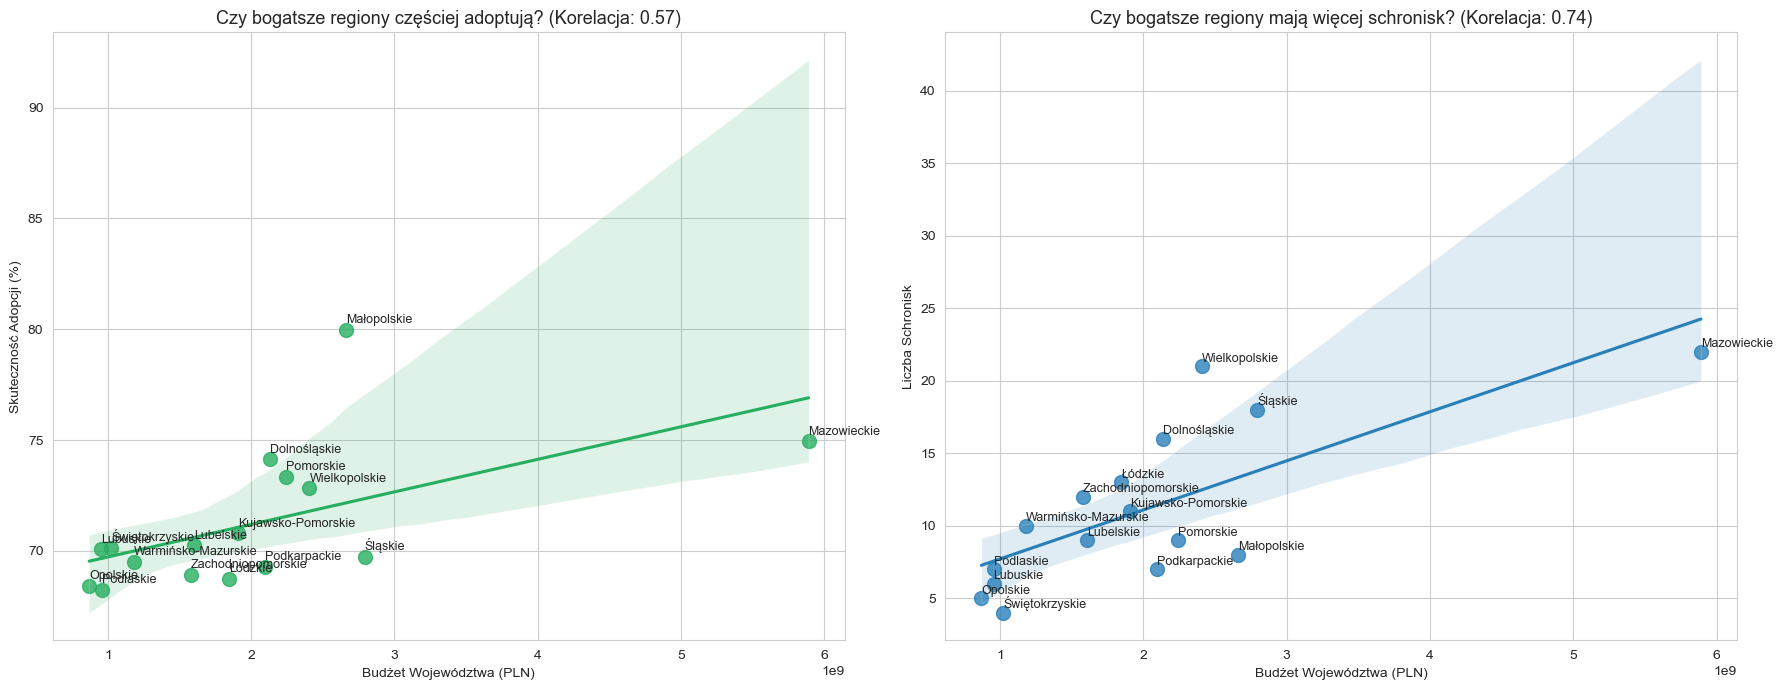

In [11]:
sns.set_style("whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# BOGACTWO vs ADOPCJA
# rysuje punkty z linią trendu
sns.regplot(ax=ax1, x=df_woj['Kwota'], y=df_koty['Adopcja_%'], color='#27ae60', scatter_kws={'s': 100})

# podpisuje punkty nazwami województw
for i in range(len(df_woj)):
    ax1.text(df_woj['Kwota'][i], df_koty['Adopcja_%'][i] + 0.3, 
             df_koty['Województwo'][i], fontsize=9)

ax1.set_title(f'Czy bogatsze regiony częściej adoptują? (Korelacja: {corr_adopcja:.2f})', fontsize=13)
ax1.set_xlabel('Budżet Województwa (PLN)')
ax1.set_ylabel('Skuteczność Adopcji (%)')
plt.savefig('wealth_vs_adoption_correlation.png', bbox_inches='tight')

# BOGACTWO vs LICZBA SCHRONISK
sns.regplot(
    ax=ax2, 
    x=df_woj['Kwota'], 
    y=df_koty['Liczba_Schronisk'],
    color='#2980b9', 
    scatter_kws={'s': 100}
)

for i in range(len(df_woj)):
    ax2.text(df_woj['Kwota'][i], df_koty['Liczba_Schronisk'][i] + 0.3, 
             df_koty['Województwo'][i], fontsize=9)

ax2.set_title(f'Czy bogatsze regiony mają więcej schronisk? (Korelacja: {corr_schroniska:.2f})', fontsize=13)
ax2.set_xlabel('Budżet Województwa (PLN)')
ax2.set_ylabel('Liczba Schronisk')

plt.tight_layout()


plt.show()

Krótkie wnioski po wykresach:
1. **Bogactwo buduje infrastrukturę (r ≈ 0.74):** Najsilniejsza zależność występuje między budżetem a liczbą schronisk. Bogatsze województwa (jak Mazowieckie) mają wyraźnie więcej placówek opiekuńczych.
2. **Pieniądze sprzyjają adopcjom (r ≈ 0.57):** Istnieje wyraźna tendencja, że w zamożniejszych regionach większy procent kotów znajduje dom. Stabilność finansowa mieszkańców i gmin przekłada się na lepsze losy zwierząt.
3. **Biedniejsi mają trudniej:** Regiony o niższym budżecie nie tylko mają mniej schronisk, ale też statystycznie trudniej jest tam o adopcję, co może skutkować przepełnieniem placówek.

## Czas na pare wykresów

#### Ranking skuteczności adopcji

C:\Users\User\AppData\Local\Temp\ipykernel_29396\3779260995.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Adopcja_%', y='Województwo', data=df_koty.sort_values('Adopcja_%', ascending=False), palette='viridis')


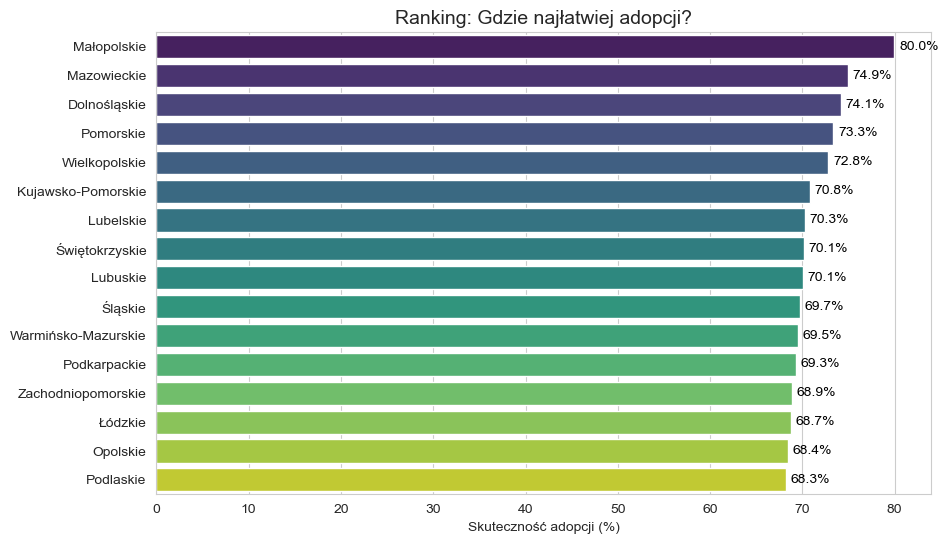

In [12]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(x='Adopcja_%', y='Województwo', data=df_koty.sort_values('Adopcja_%', ascending=False), palette='viridis')

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5, 
            p.get_y() + p.get_height() / 2, 
            f'{width:.1f}%',
            ha='left', va='center', fontsize=10, color='black')

plt.title('Ranking: Gdzie najłatwiej adopcji?', fontsize=14)
plt.xlabel('Skuteczność adopcji (%)')
plt.ylabel('')
plt.savefig('adoption_rate_ranking.png', bbox_inches='tight')

plt.show()

* **Lider:** na szczycie znajduje się województwo małoposkie z pawie 80% skuteczności adopcji
* **Nierówność szans:** wykres dowodzi, że geografia determinuje los, kot w regionie lidera ma statystycznie o ok. 10 punktów procentowych większą szansę na dom niż kot z końca stawki.

#### Wykres skumulowany

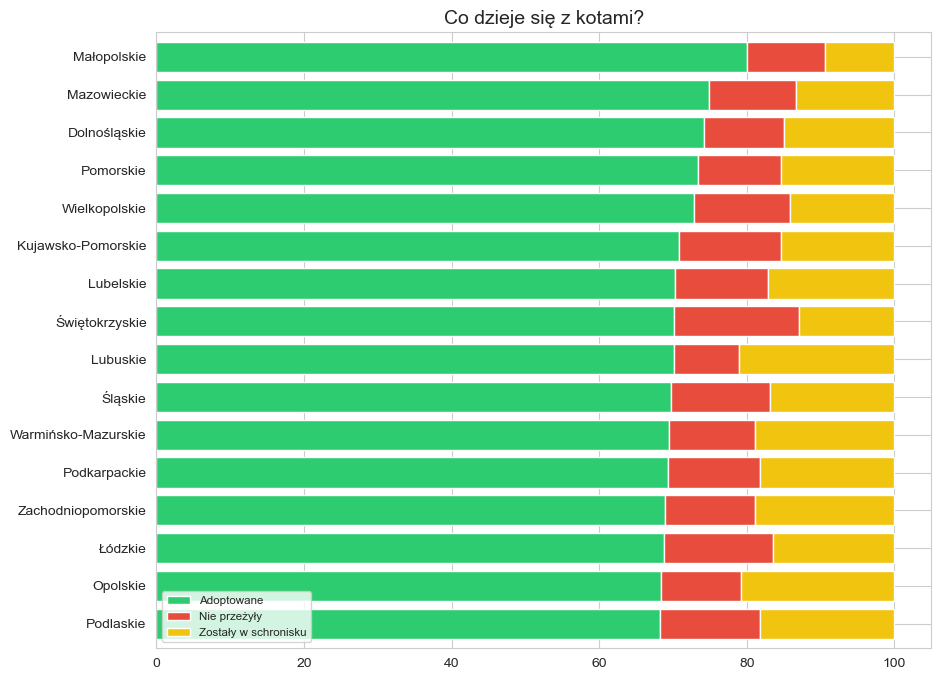

In [13]:
df_stacked = df_koty.set_index('Województwo')[['Adopcja_%', 'Smiertelnosc_%', 'Zostaly_%']].sort_values('Adopcja_%')

ax = df_stacked.plot(kind='barh', stacked=True, color=['#2ecc71', '#e74c3c', '#f1c40f'], width=0.8, figsize=(10, 8))
plt.title('Co dzieje się z kotami?', fontsize=14)
plt.legend(['Adoptowane', 'Nie przeżyły', 'Zostały w schronisku'], loc='lower left', fontsize='small')
plt.ylabel('')
plt.savefig('shelter_outcome_distribution.png', bbox_inches='tight')
plt.show()

* kolor zielony dominuje co dobrze świadczy o zainteresowaniu adopcją
* niestety pasek żółty pokazuje, że wciąż duża część kotów zostaje w schroniskach 

#### Pokazanie % śmiertelności

C:\Users\User\AppData\Local\Temp\ipykernel_29396\3371066450.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Smiertelnosc_%', y='Województwo',


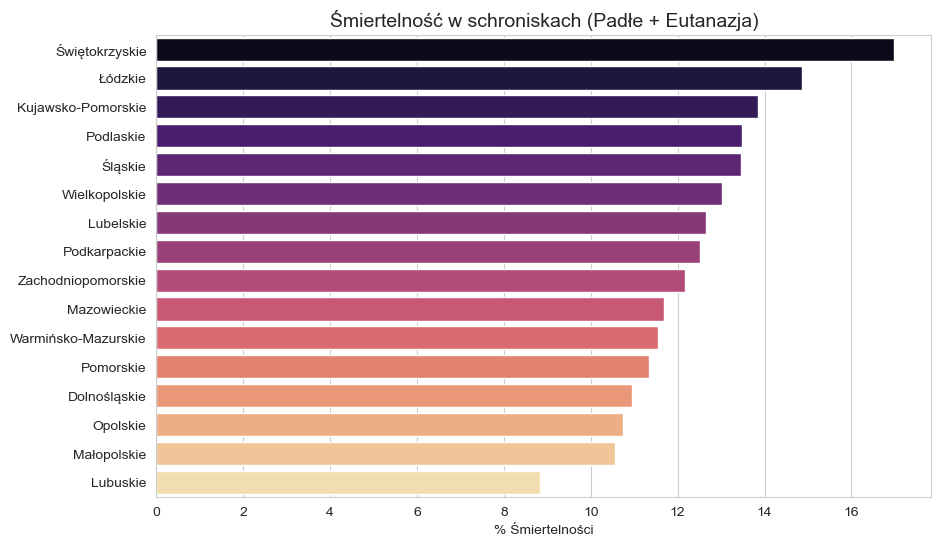

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Smiertelnosc_%', y='Województwo', 
            data=df_koty.sort_values('Smiertelnosc_%', ascending=False), 
            palette='magma')
plt.title('Śmiertelność w schroniskach (Padłe + Eutanazja)', fontsize=14)
plt.xlabel('% Śmiertelności')
plt.ylabel('')
plt.show()

* Województwa o wysokiej śmiertelnosci potrzebują interwencji i pomocy, ponieważ tam szansa na przeżycie kota jest niska.
  

#### Jak rozkłada się skuteczność adopcji?

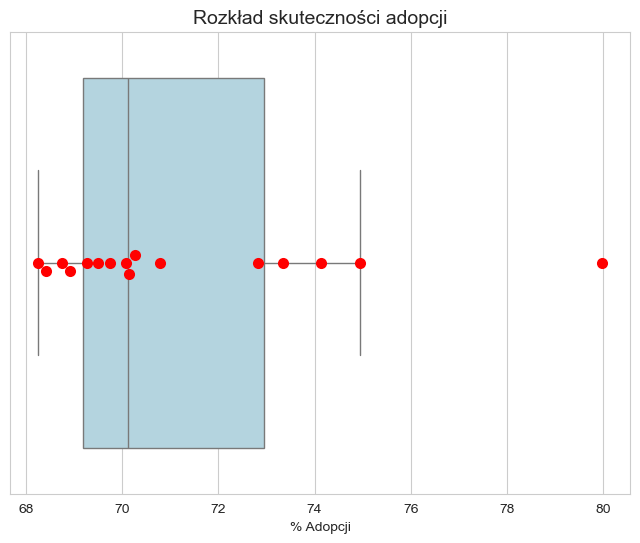

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_koty['Adopcja_%'], color='lightblue')
sns.swarmplot(x=df_koty['Adopcja_%'], color='red', size=8)
plt.title('Rozkład skuteczności adopcji', fontsize=14)
plt.xlabel('% Adopcji')
plt.show()

Krótka analiza odemnie:
* **Stabilność:** sytuacja w polsce jest całkiem wyrównana, czyli większość województw mieści się w "pudełku", czyli osiąga wynik adopcji między 69% a 73%


#### Mapka dla lepszego zwizualizowania

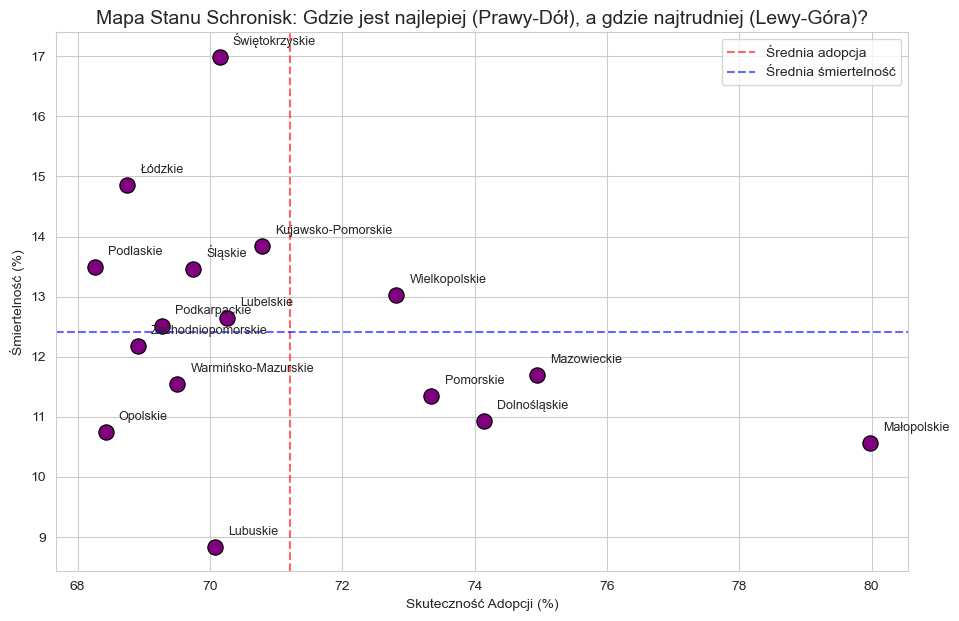

In [16]:
mean_adopcja = df_koty['Adopcja_%'].mean()
mean_smierc = df_koty['Smiertelnosc_%'].mean()

plt.figure(figsize=(11, 7))
# rysuje punkty
sns.scatterplot(x='Adopcja_%', y='Smiertelnosc_%', data=df_koty, s=120, color='purple', edgecolor='black')

# linie średnich (ćwiartki)
plt.axvline(x=mean_adopcja, color='red', linestyle='--', alpha=0.6, label='Średnia adopcja')
plt.axhline(y=mean_smierc, color='blue', linestyle='--', alpha=0.6, label='Średnia śmiertelność')

# podpisy miast
for i in range(len(df_koty)):
    plt.text(df_koty['Adopcja_%'][i]+0.2, df_koty['Smiertelnosc_%'][i]+0.2, 
             df_koty['Województwo'][i], fontsize=9)

plt.title('Mapa Stanu Schronisk: Gdzie jest najlepiej (Prawy-Dół), a gdzie najtrudniej (Lewy-Góra)?', fontsize=14)
plt.xlabel('Skuteczność Adopcji (%)')
plt.ylabel('Śmiertelność (%)')
plt.legend()
plt.savefig('adoption_vs_mortality_analysis.png', bbox_inches='tight')
plt.show()

Szybkie wnioski pod wykresem:
1. **Liderzy (Prawy dolny róg):** województwa w tej ćwiartce radzą sobie najlepiej, mają wysoką skuteczność adopcji i niska śmiertelność, co świadczy o dobrej opiere weterynaryjnej i zaineresowaniem adopcją --> Małopolski
2. **Obszar krytyczny (Lewy górny róg):** w tej części regiony wymagają interwencji, mają niskie zainteresowanie adopcją oraz bardzo wysoką śmiertelność --> Świętokrzyskie
---


## Wnioski końcowe

1. Istnieje silna zależność (korelacja ≈ 0.74) między zamożnością regionu, a liczbą dostępnych schronisk. Województwa dysponujące większym budżetem (np. mazowieckie) inwestują więcej w schroniska, co zwiększa szanse na profesjonalną opiekę nod bezdomnymi zwierzętami.
2. Analiza wykresów (Mapa stanu schronisk) pozwala pidentyfikować "obszary krytyczne" - wojewódżtwa o niskim budżecie, które borykaja się z wysoką śmiertelnością i niską ilością adopcji. Może to wskazywać na konieczność systemowego wsparcia tych regionów.
3. Dobrostan bezdomnych kotków w Polsce jest ściśle powiązany z czynnikami ekonomicznymi. Szansa na przeżycie i znalezienie domku przez kocura jest statystycznie większa w regionach bogatszych.